## Entrenamiento de la detección del recuadro de juego (realizado en Google Colab)

### Instalo Ultralytics

In [5]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 37.2 MB/s eta 0:00:00


### Accedo a Google Drive para obtener imágenes y etiquetas para el entrenamiento

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Llamo al modelo y lo entreno para detectar el recuadro de juego

In [8]:
from ultralytics import YOLO

modelo = YOLO('yolo11n.pt')

modelo.train(
    # Archivo yaml para definir el dataset.
    data="/content/drive/MyDrive/Sudoku/data.yaml",
    epochs=30,  # Numero de epocas que defino.
    batch=32,   #Tamaño de batch.
    imgsz=640,  # Tamaño de las imagenes.
    project="sudoku",  # Carpeta donde se guardará el entrenamiento.
    name="sudoku",  # Nombre del modelo.
    save=True,      # Guardar el modelo después de entrenar.
    exist_ok=True   # Sobrescribir resultados si ya existe una carpeta.
)

Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Sudoku/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=sudoku, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pat

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78acec26f920>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

### Cargo el modelo y la imagen para comprobar cómo es la detección


image 1/1 /content/drive/MyDrive/Sudoku/001.png: 640x480 1 sudoku, 53.0ms
Speed: 2.4ms preprocess, 53.0ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 480)


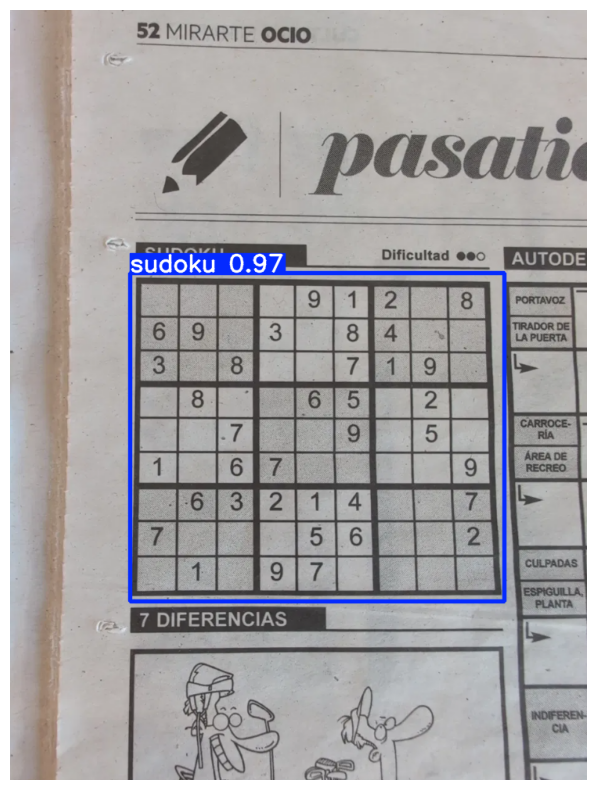

'results_001.png'

In [9]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

modelo = YOLO('/content/runs/detect/sudoku/sudoku/weights/best.pt')

ruta_imagen = '/content/drive/MyDrive/Sudoku/001.png'

results = modelo(ruta_imagen)

img = results[0].plot()
plt.figure(figsize=(10, 10))
plt.imshow(img[..., ::-1])
plt.axis('off')
plt.show()

results[0].save()